# BizIntel — Unified Startup Data Analysis
Quick exploratory analysis of `startups_unified.csv` produced by the preprocessing pipeline.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)

DATA_PATH = Path("data/startups_unified.csv")
df = pd.read_csv(DATA_PATH)
print(f"Rows: {len(df):,}  |  Columns: {len(df.columns)}")
df.head()

Rows: 134,092  |  Columns: 9


,startup_id,name,description,industry,tags,country,founded_year,source,is_suspicious
0,28425,Pando Bioscience,Pando Bioscience is a Boston-based synthetic b...,Drug discovery,"Drug discovery, Biotech, Diagnostics, Syntheti...",US,2022.0,YC,False
1,28421,Apollo Group,Apollo Group is a diversified technology group...,Home Services,"Home Services, International, Marketplace, Con...",PK,2023.0,YC,False
2,28416,Pierre,"Pierre enables engineers, designers and busine...",Developer Tools,"Developer Tools, Collaboration, AI-Enhanced Le...",US,2023.0,YC,False
3,28415,moonrepo,moonrepo is a developer tool that reduces buil...,Developer Tools,"Developer Tools, SaaS, Open Source, Enterprise...",US,2022.0,YC,False
4,28414,Lasso,🧐 The problem: Traditional Robotic Process Aut...,Generative AI,"Generative AI, B2B, SaaS, Developer Tools, Art...",US,2023.0,YC,False


## 1. Source Distribution — YC vs Crunchbase

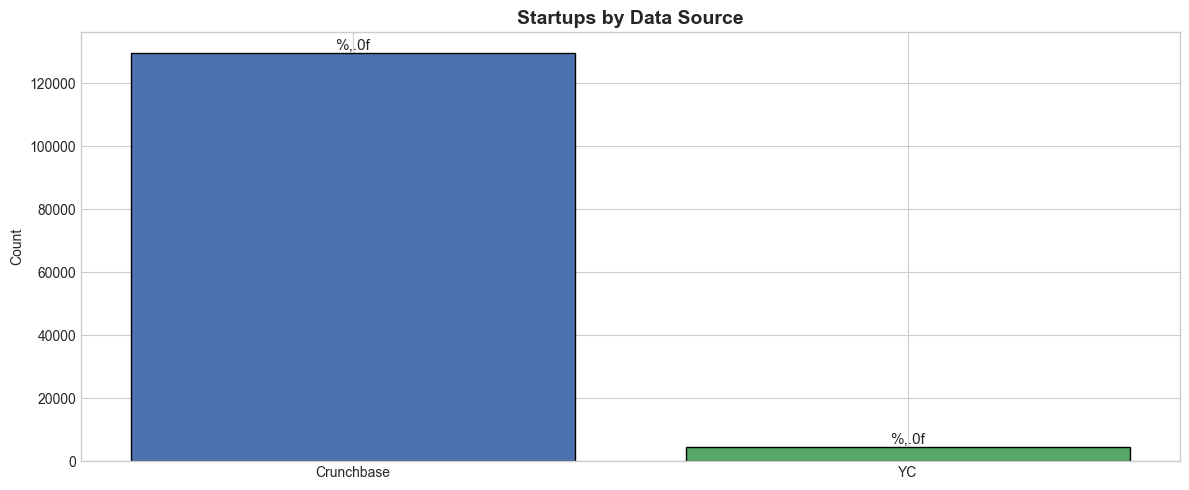

In [2]:
source_counts = df["source"].value_counts()

fig, ax = plt.subplots()
colors = ["#4C72B0", "#55A868"]
bars = ax.bar(source_counts.index, source_counts.values, color=colors, edgecolor="black")
ax.bar_label(bars, fmt="%,.0f", fontsize=11)
ax.set_title("Startups by Data Source", fontsize=14, fontweight="bold")
ax.set_ylabel("Count")
plt.tight_layout()
plt.show()

## 2. Top 15 Countries by Startup Count

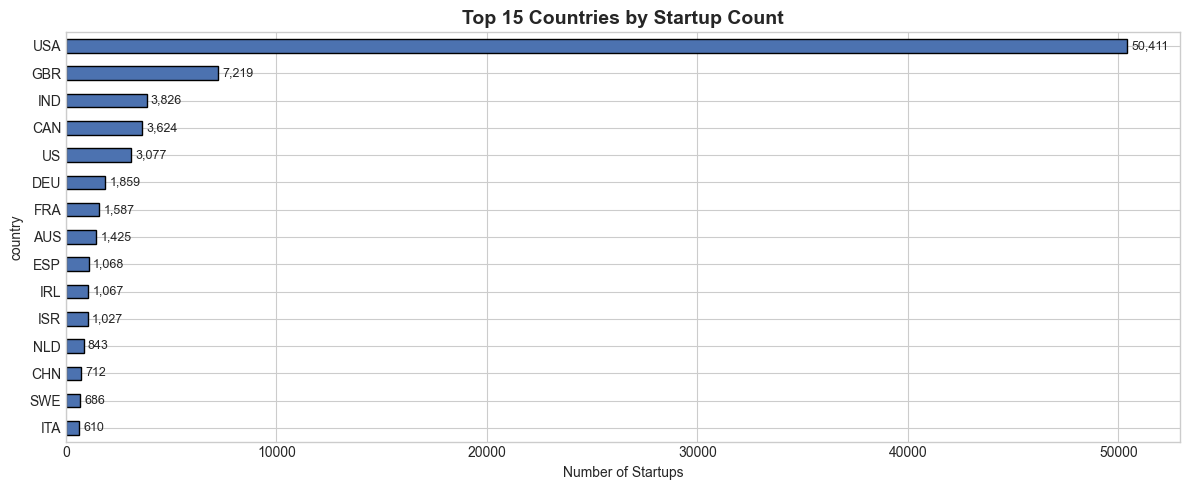

In [3]:
top_countries = df["country"].value_counts().head(15)

fig, ax = plt.subplots()
top_countries.plot.barh(ax=ax, color="#4C72B0", edgecolor="black")
ax.invert_yaxis()
ax.set_title("Top 15 Countries by Startup Count", fontsize=14, fontweight="bold")
ax.set_xlabel("Number of Startups")
for i, v in enumerate(top_countries.values):
    ax.text(v + 200, i, f"{v:,}", va="center", fontsize=9)
plt.tight_layout()
plt.show()

## 3. Top 15 Industries

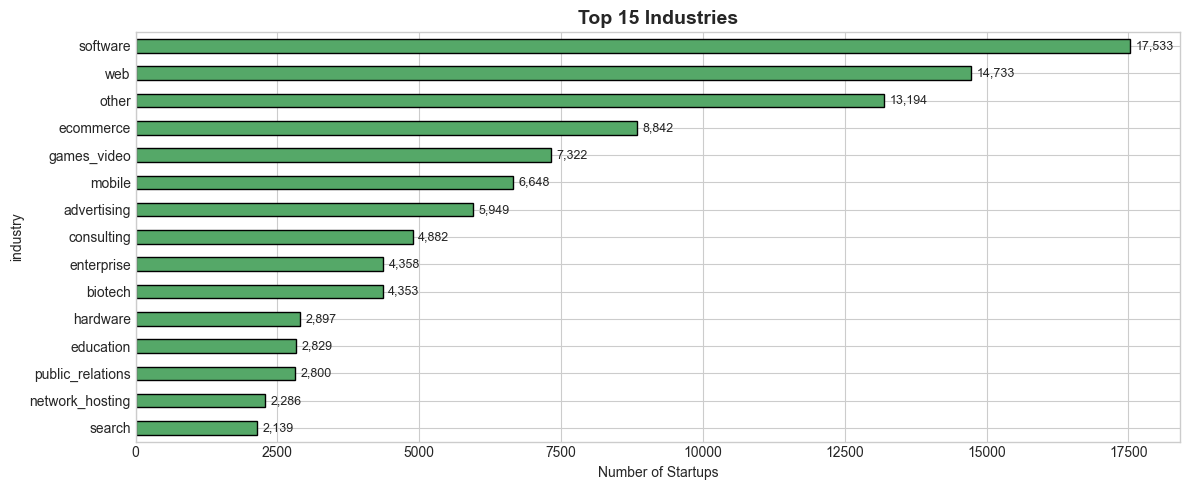

In [4]:
top_industries = df["industry"].replace("", pd.NA).dropna().value_counts().head(15)

fig, ax = plt.subplots()
top_industries.plot.barh(ax=ax, color="#55A868", edgecolor="black")
ax.invert_yaxis()
ax.set_title("Top 15 Industries", fontsize=14, fontweight="bold")
ax.set_xlabel("Number of Startups")
for i, v in enumerate(top_industries.values):
    ax.text(v + 100, i, f"{v:,}", va="center", fontsize=9)
plt.tight_layout()
plt.show()

## 4. Startups Founded Per Year (1995–2023)

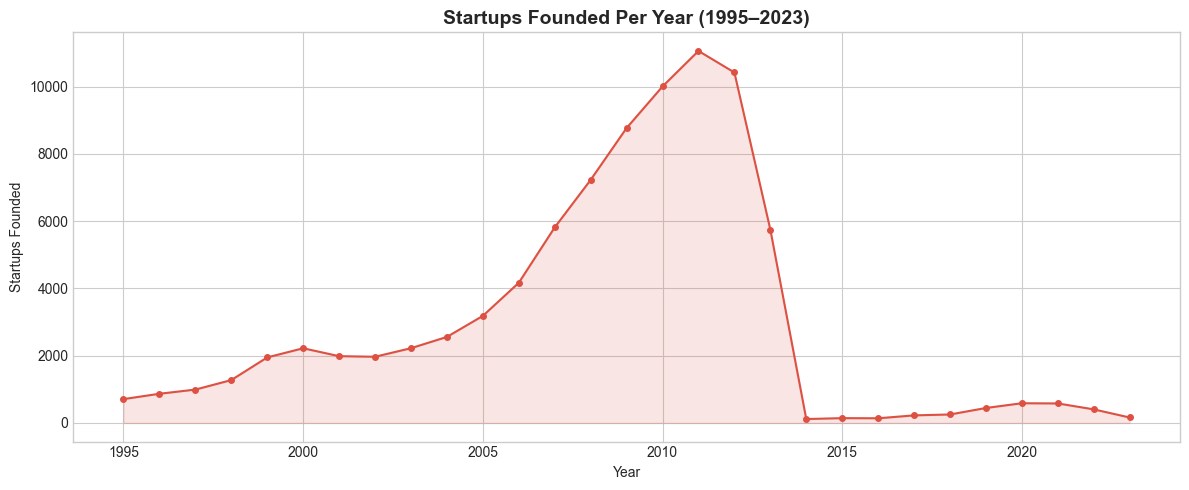

In [5]:
yearly = (
    df[df["founded_year"].between(1995, 2023)]
    .groupby("founded_year")
    .size()
    .reset_index(name="count")
)

fig, ax = plt.subplots()
ax.plot(yearly["founded_year"], yearly["count"], marker="o", markersize=4, color="#DD5143")
ax.fill_between(yearly["founded_year"], yearly["count"], alpha=0.15, color="#DD5143")
ax.set_title("Startups Founded Per Year (1995–2023)", fontsize=14, fontweight="bold")
ax.set_xlabel("Year")
ax.set_ylabel("Startups Founded")
plt.tight_layout()
plt.show()

## 5. YC vs Crunchbase — Founded Year Distribution

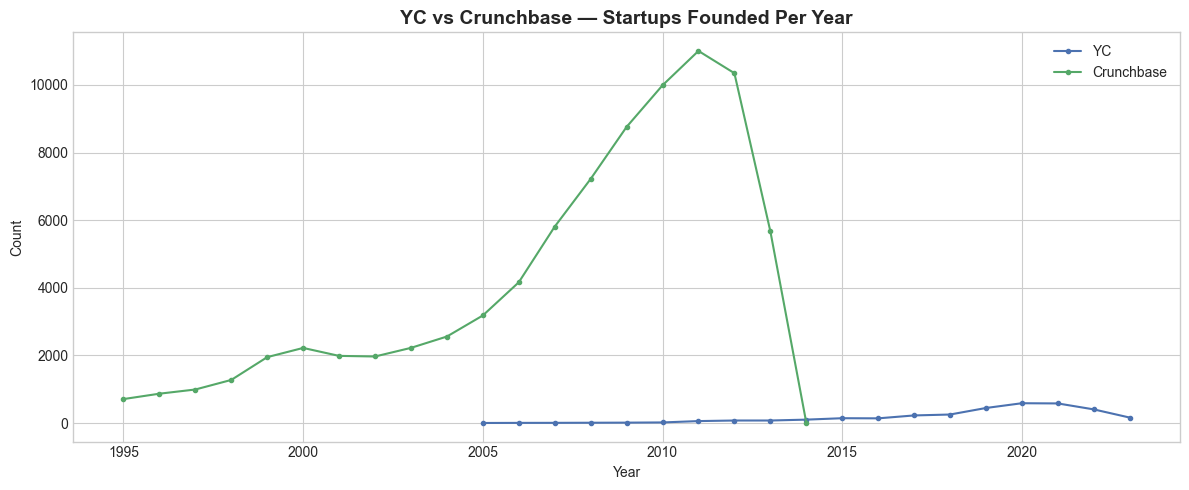

In [6]:
fig, ax = plt.subplots()
for source, color in [("YC", "#4C72B0"), ("Crunchbase", "#55A868")]:
    subset = df[(df["source"] == source) & df["founded_year"].between(1995, 2023)]
    yearly_src = subset.groupby("founded_year").size()
    ax.plot(yearly_src.index, yearly_src.values, label=source, marker="o", markersize=3, color=color)
ax.set_title("YC vs Crunchbase — Startups Founded Per Year", fontsize=14, fontweight="bold")
ax.set_xlabel("Year")
ax.set_ylabel("Count")
ax.legend()
plt.tight_layout()
plt.show()

## 6. Suspicious vs Clean Records

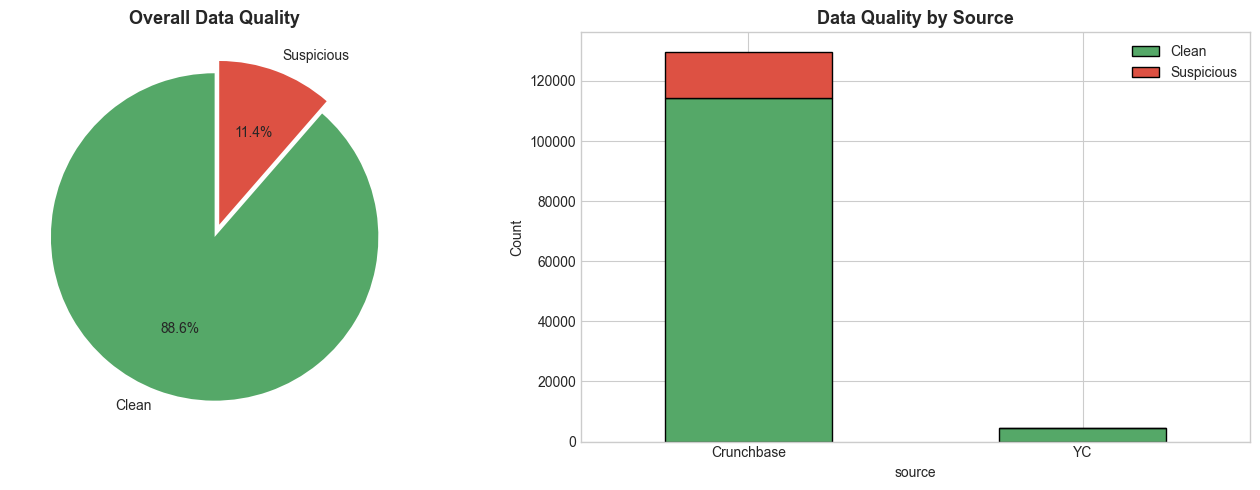

In [7]:
sus_counts = df["is_suspicious"].value_counts().rename({True: "Suspicious", False: "Clean"})

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Pie chart
axes[0].pie(
    sus_counts.values,
    labels=sus_counts.index,
    autopct="%1.1f%%",
    colors=["#55A868", "#DD5143"],
    startangle=90,
    explode=(0, 0.08),
)
axes[0].set_title("Overall Data Quality", fontsize=13, fontweight="bold")

# Stacked bar by source
quality = df.groupby(["source", "is_suspicious"]).size().unstack(fill_value=0)
quality.columns = ["Clean", "Suspicious"]
quality.plot.bar(stacked=True, ax=axes[1], color=["#55A868", "#DD5143"], edgecolor="black")
axes[1].set_title("Data Quality by Source", fontsize=13, fontweight="bold")
axes[1].set_ylabel("Count")
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0)

plt.tight_layout()
plt.show()

## 7. Description Length Distribution

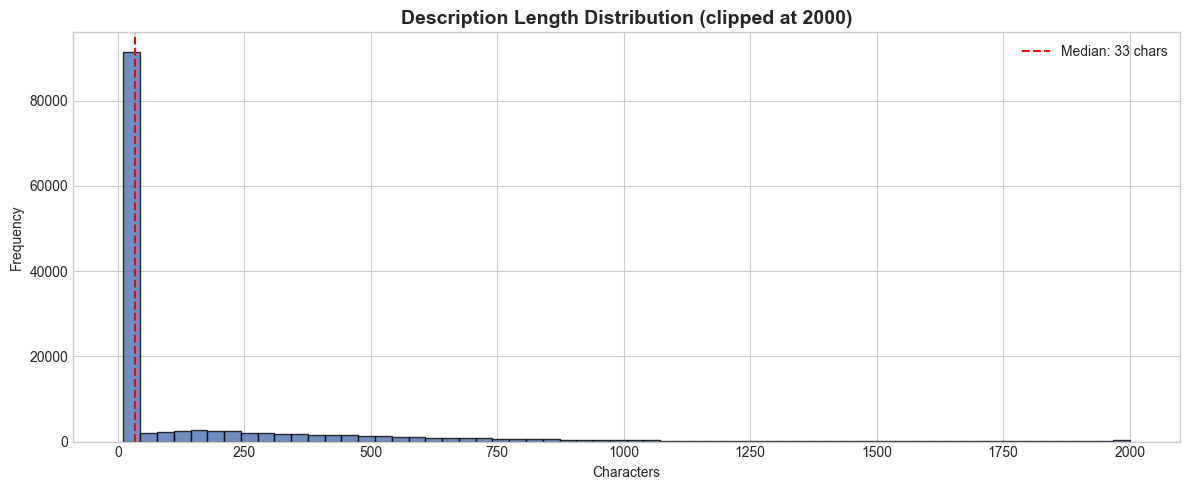

In [8]:
df["desc_len"] = df["description"].fillna("").str.len()

fig, ax = plt.subplots()
ax.hist(df["desc_len"].clip(upper=2000), bins=60, color="#4C72B0", edgecolor="black", alpha=0.8)
ax.axvline(df["desc_len"].median(), color="red", linestyle="--", label=f"Median: {df['desc_len'].median():.0f} chars")
ax.set_title("Description Length Distribution (clipped at 2000)", fontsize=14, fontweight="bold")
ax.set_xlabel("Characters")
ax.set_ylabel("Frequency")
ax.legend()
plt.tight_layout()
plt.show()

df.drop(columns=["desc_len"], inplace=True)

## 8. Quick Summary Stats

In [9]:
print(f"Total startups          : {len(df):,}")
print(f"Unique countries        : {df['country'].nunique()}")
print(f"Unique industries       : {df['industry'].replace('', pd.NA).dropna().nunique()}")
print(f"YC startups             : {(df['source']=='YC').sum():,}")
print(f"Crunchbase startups     : {(df['source']=='Crunchbase').sum():,}")
print(f"Suspicious records      : {df['is_suspicious'].sum():,} ({df['is_suspicious'].mean()*100:.1f}%)")
print(f"Median founded year     : {df['founded_year'].median():.0f}")
print(f"Median description len  : {df['description'].str.len().median():.0f} chars")

Total startups          : 134,092
Unique countries        : 254
Unique industries       : 313
YC startups             : 4,399
Crunchbase startups     : 129,693
Suspicious records      : 15,285 (11.4%)
Median founded year     : 2009
Median description len  : 33 chars


## 9. Export Unified Data to JSON & Excel

In [10]:
import re
from pathlib import Path

output_dir = Path("data")

# --- Export to JSON ---
json_path = output_dir / "startups_unified.json"
df.to_json(json_path, orient="records", indent=2, force_ascii=False)
print(f"✅ Exported JSON  : {json_path}  ({len(df):,} records)")

# --- Export to Excel ---
# Sanitize text: remove illegal control characters that openpyxl rejects
ILLEGAL_CHARS = re.compile(r"[\x00-\x08\x0b\x0c\x0e-\x1f]")
df_excel = df.copy()
for col in df_excel.select_dtypes(include="object").columns:
    df_excel[col] = df_excel[col].fillna("").apply(lambda v: ILLEGAL_CHARS.sub("", str(v)))

excel_path = output_dir / "startups_unified.xlsx"
df_excel.to_excel(excel_path, index=False, sheet_name="startups")
print(f"✅ Exported Excel : {excel_path} ({len(df):,} records)")

✅ Exported JSON  : data\startups_unified.json  (134,092 records)
✅ Exported Excel : data\startups_unified.xlsx (134,092 records)
✅ Exported Excel : data\startups_unified.xlsx (134,092 records)


In [12]:
path1="C:\\Users\\ShubhankDubey\\Shubhank_All\\EPAM-2026\\learning-projects\\BizIntel\\data-source\\2023-07-13-yc-companies.csv"
df1=pd.read_csv(path1)

In [16]:
#df1.groupby(['company_name','country']).aggregate({'year': 'first'})